In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('C:\\Users\\YUSUF MOShood\\Documents\\ds_salary_proj\\salary_data_cleaned.csv')

In [3]:
df.head()

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,...,avg_salary,company_txt,job_state,same_state,age,python_yn,r_yn,spark,aws,excel
0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,Company - Private,...,72.0,Tecolote Research\n,NM,0,47,1,0,0,0,1
1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,Other Organization,...,87.5,University of Maryland Medical System\n,MD,0,36,1,0,0,0,0
2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,Company - Private,...,85.0,KnowBe4\n,FL,1,10,1,0,1,0,1
3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,Government,...,76.5,PNNL\n,WA,1,55,1,0,0,0,0
4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,...,114.5,Affinity Solutions\n,NY,1,22,1,0,0,0,1


In [4]:
df.columns

Index(['Job Title', 'Salary Estimate', 'Job Description', 'Rating',
       'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'hourly', 'employer_provided', 'min_salary', 'max_salary', 'avg_salary',
       'company_txt', 'job_state', 'same_state', 'age', 'python_yn', 'r_yn',
       'spark', 'aws', 'excel'],
      dtype='object')

In [5]:
def title_simplifier(title):
    if 'data scientist' in title.lower():
        return 'data scientist'
    elif 'data engineer' in title.lower():
        return 'data engineer'
    elif 'analyst' in title.lower():
        return 'analyst'
    elif 'machine learning' in title.lower():
        return 'mle'
    elif 'manager' in title.lower():
        return 'manager'
    elif 'director' in title.lower():
        return 'director'
    else:
        return 'na'

def seniority(title):
    if 'sr' in title.lower() or 'senior' in title.lower() or 'lead' in title.lower() or 'principal' in title.lower():
        return 'senior'
    elif 'jr' in title.lower() or 'junior' in title.lower() or 'trainee' in title.lower() or 'intern' in title.lower():
        return 'junior'
    else:
        return 'na'

In [6]:
df['job_simp'] = df['Job Title'].apply(title_simplifier)

In [7]:
df.job_simp.value_counts()

job_simp
data scientist    279
na                184
data engineer     119
analyst           102
manager            22
mle                22
director           14
Name: count, dtype: int64

In [8]:
df['seniority'] = df['Job Title'].apply(seniority)
df.seniority.value_counts()

seniority
na        517
senior    220
junior      5
Name: count, dtype: int64

In [9]:

df['job_state']=df.job_state.apply(lambda x: x.strip() if x.strip().lower() != 'los angeles' else 'CA')
df.job_state.value_counts()

job_state
CA    152
MA    103
NY     72
VA     41
IL     40
MD     35
PA     33
TX     28
NC     21
WA     21
NJ     17
FL     16
OH     14
TN     13
DC     11
CO     11
WI     10
UT     10
IN     10
AZ      9
MO      9
AL      8
GA      6
DE      6
KY      6
MI      6
CT      5
IA      5
LA      4
OR      4
NE      4
NM      3
KS      3
ID      2
MN      2
RI      1
SC      1
Name: count, dtype: int64

In [10]:
df.shape

(742, 30)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.shape

(467, 30)

In [13]:
df['desc_lenght'] = df['Job Description'].apply(lambda x: len(x))
df['desc_lenght']

0      2536
1      4783
2      3461
3      3883
4      2728
       ... 
695    4023
700     407
716    3911
732    3478
735    3813
Name: desc_lenght, Length: 467, dtype: int64

In [14]:
df['no_Competitors'] = df['Competitors'].apply(lambda x: len(x.split(',')) if x != '-1' else 0)

In [15]:
df['no_Competitors']

0      0
1      0
2      0
3      3
4      3
      ..
695    1
700    0
716    3
732    0
735    2
Name: no_Competitors, Length: 467, dtype: int64

In [16]:
df['min_salary'] = df.apply(lambda x: x.min_salary*2 if x.hourly ==1 else x.min_salary, axis=1)
df['max_salary'] = df.apply(lambda x: x.max_salary*2 if x.hourly ==1 else x.max_salary, axis=1)
df[['min_salary','max_salary','hourly']]

,min_salary,max_salary,hourly
0,53,91,0
1,63,112,0
2,80,90,0
3,56,97,0
4,86,143,0
...,...,...,...
695,63,110,0
700,65,113,0
716,59,125,0
732,80,142,0


In [17]:
df[df.hourly==1][['min_salary','max_salary','hourly']]

,min_salary,max_salary,hourly
165,34,48,1
177,42,68,1
197,36,50,1
202,42,68,1
210,30,50,1
345,48,78,1
363,50,56,1
408,42,58,1
409,20,34,1
645,54,94,1


In [18]:
df['company_txt']= df.company_txt.apply(lambda x: x.replace('\n',""))

In [19]:
df['company_txt']

0                          Tecolote Research
1      University of Maryland Medical System
2                                    KnowBe4
3                                       PNNL
4                         Affinity Solutions
                       ...                  
695                       Medidata Solutions
700                          DatamanUSA, LLC
716                                  23andMe
732                         CK-12 Foundation
735                                Fivestars
Name: company_txt, Length: 467, dtype: object

In [20]:
df.describe()

,Rating,Founded,hourly,employer_provided,min_salary,max_salary,avg_salary,same_state,age,python_yn,r_yn,spark,aws,excel,desc_lenght,no_Competitors
count,467.000000,467.000000,467.000000,467.000000,467.000000,467.000000,467.000000,467.000000,467.000000,467.000000,467.000000,467.000000,467.000000,467.000000,467.000000,467.000000
mean,3.651820,1832.441113,0.021413,0.021413,74.760171,128.269807,100.978587,0.537473,44.676660,0.556745,0.002141,0.237687,0.237687,0.535332,3812.766595,1.085653
std,0.805355,508.661732,0.144913,0.144913,29.943980,44.002780,37.318755,0.499128,52.429355,0.497302,0.046274,0.426123,0.426123,0.499285,1528.052301,1.397863
min,-1.000000,-1.000000,0.000000,0.000000,15.000000,16.000000,13.500000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,407.000000,0.000000
25%,3.400000,1939.000000,0.000000,0.000000,53.500000,98.000000,76.000000,0.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2729.000000,0.000000
50%,3.700000,1991.000000,0.000000,0.000000,71.000000,124.000000,97.500000,1.000000,24.000000,1.000000,0.000000,0.000000,0.000000,1.000000,3703.000000,0.000000
75%,4.100000,2007.000000,0.000000,0.000000,90.500000,150.000000,121.000000,1.000000,55.000000,1.000000,0.000000,0.000000,0.000000,1.000000,4704.000000,3.000000
max,5.000000,2019.000000,1.000000,1.000000,202.000000,306.000000,254.000000,1.000000,276.000000,1.000000,1.000000,1.000000,1.000000,1.000000,10051.000000,4.000000


In [21]:
df.columns

Index(['Job Title', 'Salary Estimate', 'Job Description', 'Rating',
       'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'hourly', 'employer_provided', 'min_salary', 'max_salary', 'avg_salary',
       'company_txt', 'job_state', 'same_state', 'age', 'python_yn', 'r_yn',
       'spark', 'aws', 'excel', 'job_simp', 'seniority', 'desc_lenght',
       'no_Competitors'],
      dtype='object')

<Axes: >

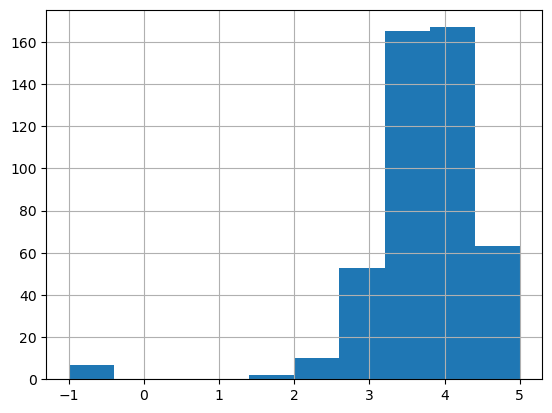

In [22]:
df.Rating.hist()

<Axes: >

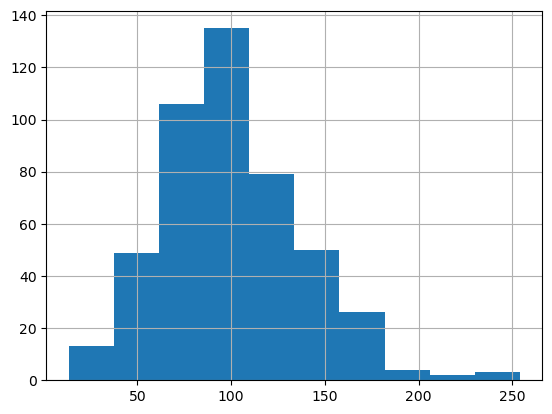

In [23]:
df.avg_salary.hist()

<Axes: >

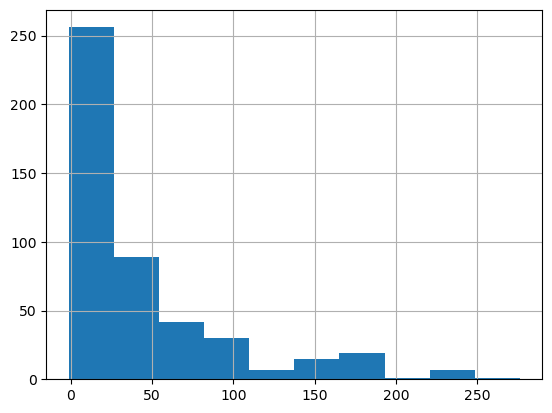

In [24]:
df.age.hist()

<Axes: >

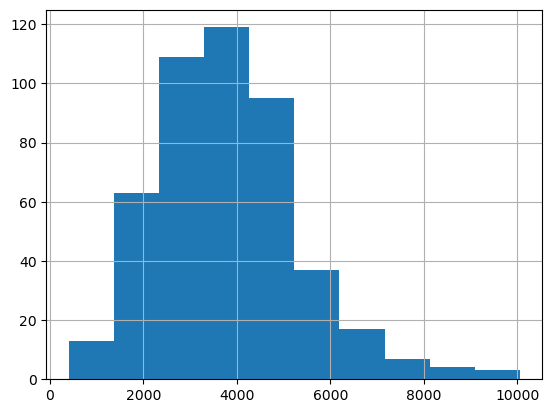

In [25]:
df.desc_lenght.hist()

<Axes: >

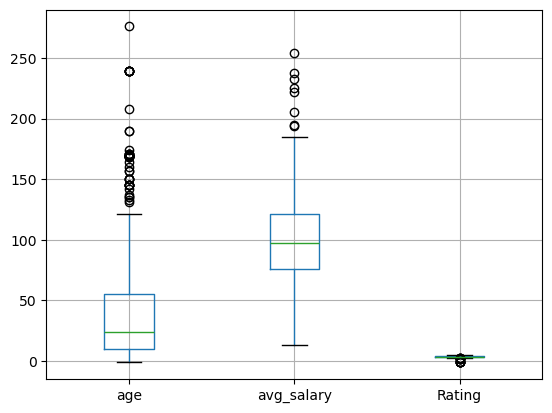

In [26]:
df.boxplot(column=['age','avg_salary','Rating'])

<Axes: >

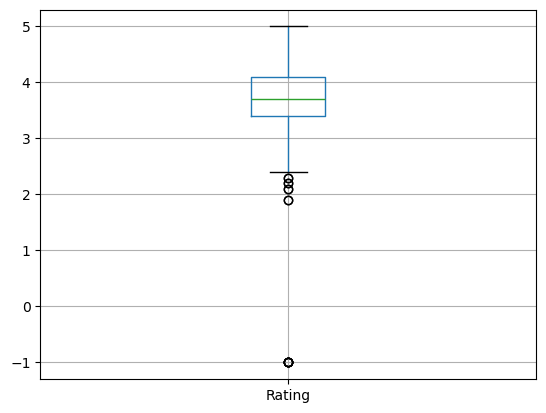

In [27]:
df.boxplot(column='Rating')

In [28]:
df[['age','avg_salary','Rating','desc_lenght']].corr()

,age,avg_salary,Rating,desc_lenght
age,1.000000,0.001994,0.012895,0.151162
avg_salary,0.001994,1.000000,0.009726,0.049744
Rating,0.012895,0.009726,1.000000,-0.040225
desc_lenght,0.151162,0.049744,-0.040225,1.000000


<Axes: >

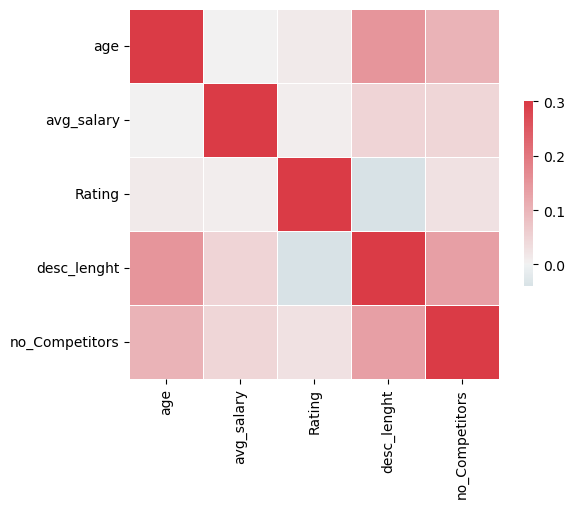

In [29]:
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(df[['age','avg_salary','Rating','desc_lenght','no_Competitors']].corr(),vmax =.3, center=0,cmap=cmap,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

In [30]:
df.columns

Index(['Job Title', 'Salary Estimate', 'Job Description', 'Rating',
       'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'hourly', 'employer_provided', 'min_salary', 'max_salary', 'avg_salary',
       'company_txt', 'job_state', 'same_state', 'age', 'python_yn', 'r_yn',
       'spark', 'aws', 'excel', 'job_simp', 'seniority', 'desc_lenght',
       'no_Competitors'],
      dtype='object')

In [31]:
df_cat=df[['Location', 'Headquarters', 'Size','Type of ownership', 'Industry', 'Sector', 'Revenue','company_txt','job_state','same_state'
    , 'spark', 'aws',
       'excel', 'job_simp', 'seniority']]

graph for Location: total = 200


C:\Users\YUSUF MOShood\AppData\Local\Temp\ipykernel_1536\3301202459.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


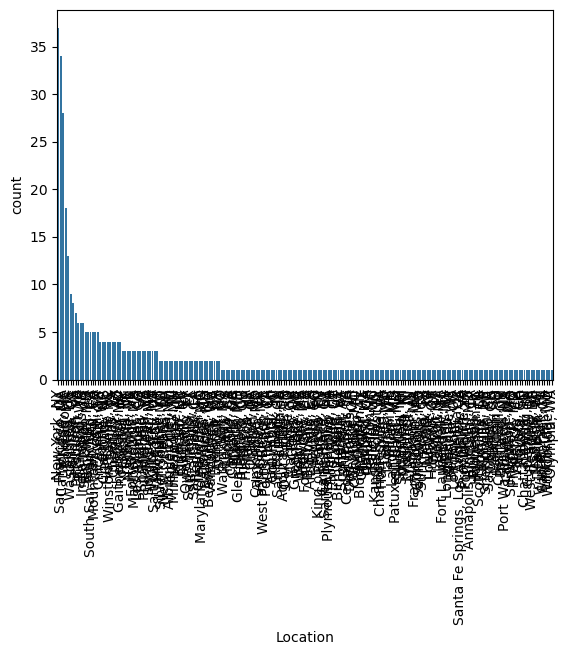

graph for Headquarters: total = 198


C:\Users\YUSUF MOShood\AppData\Local\Temp\ipykernel_1536\3301202459.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


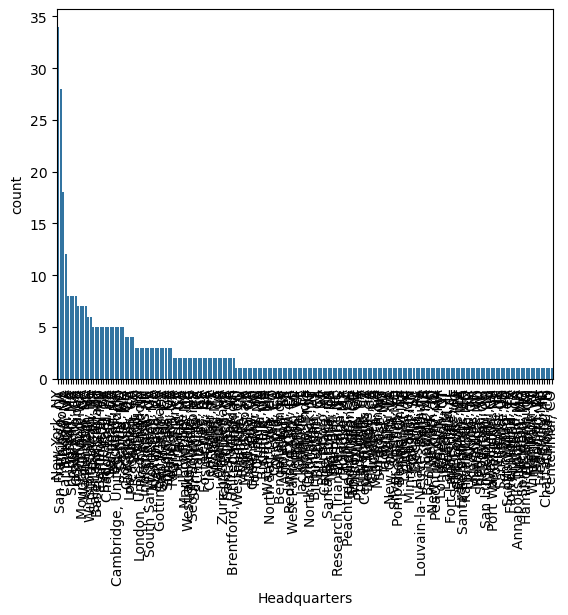

graph for Size: total = 9


C:\Users\YUSUF MOShood\AppData\Local\Temp\ipykernel_1536\3301202459.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


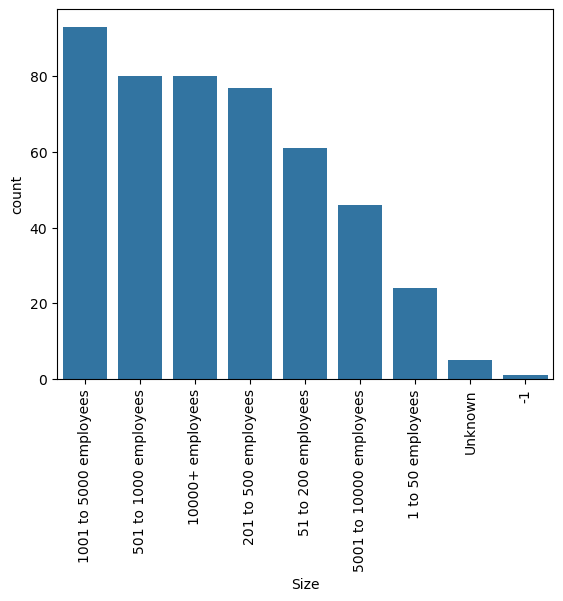

graph for Type of ownership: total = 11


C:\Users\YUSUF MOShood\AppData\Local\Temp\ipykernel_1536\3301202459.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


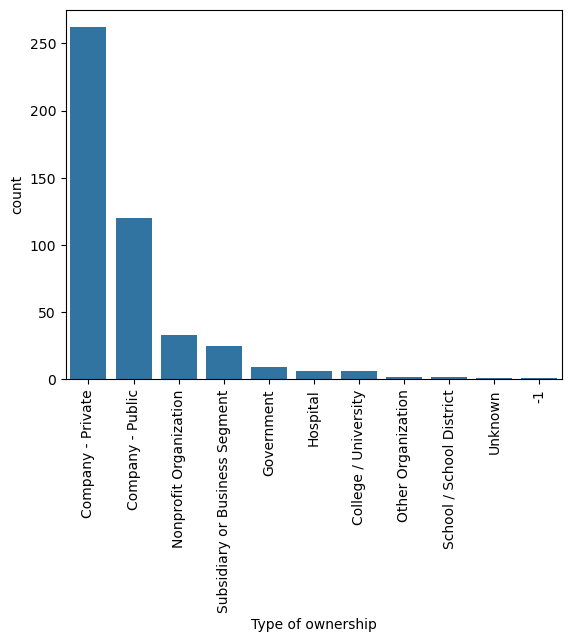

graph for Industry: total = 60


C:\Users\YUSUF MOShood\AppData\Local\Temp\ipykernel_1536\3301202459.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


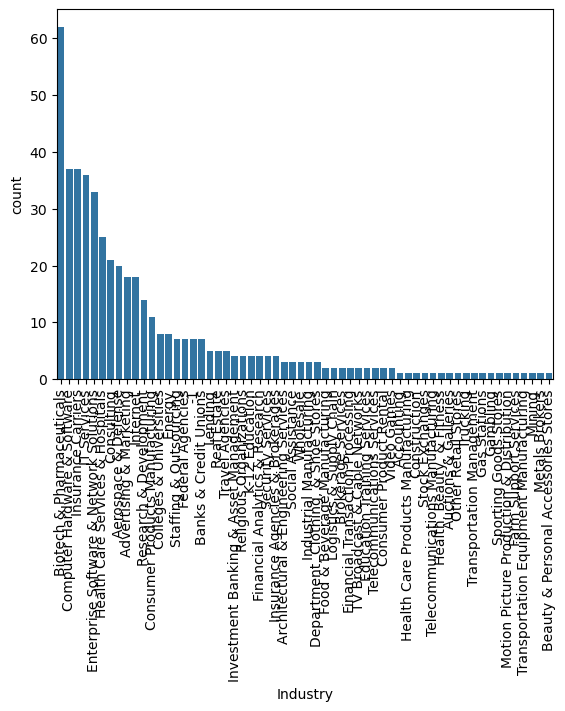

graph for Sector: total = 25


C:\Users\YUSUF MOShood\AppData\Local\Temp\ipykernel_1536\3301202459.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


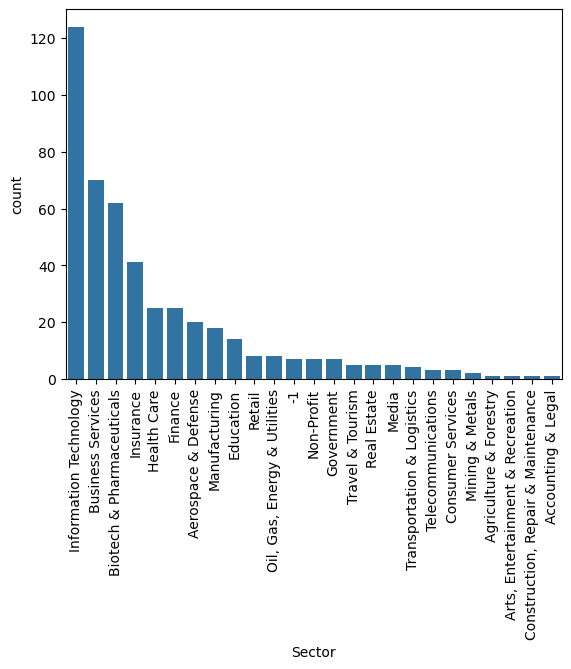

graph for Revenue: total = 14


C:\Users\YUSUF MOShood\AppData\Local\Temp\ipykernel_1536\3301202459.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


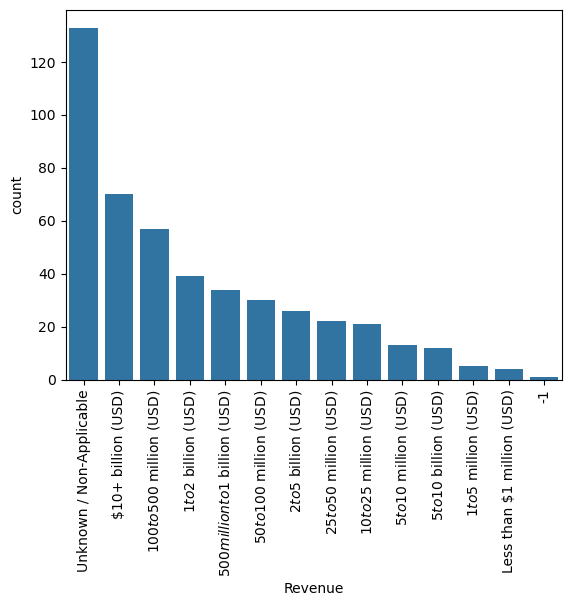

graph for company_txt: total = 343


C:\Users\YUSUF MOShood\AppData\Local\Temp\ipykernel_1536\3301202459.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


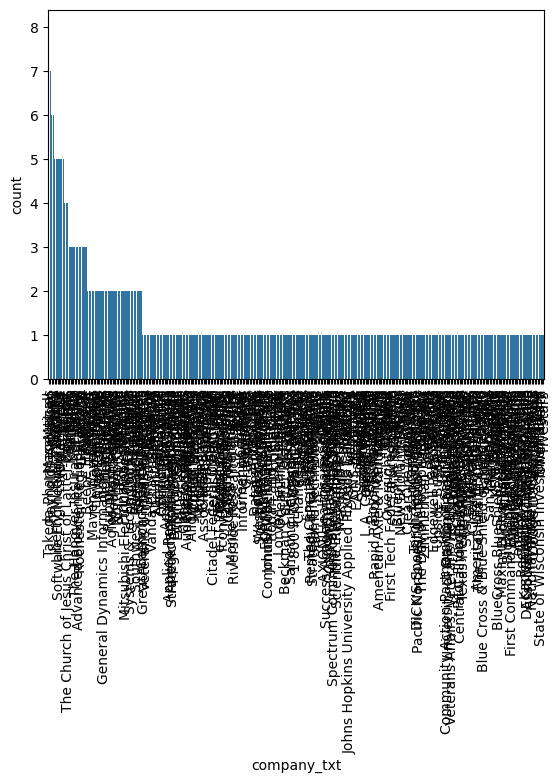

graph for job_state: total = 37


C:\Users\YUSUF MOShood\AppData\Local\Temp\ipykernel_1536\3301202459.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


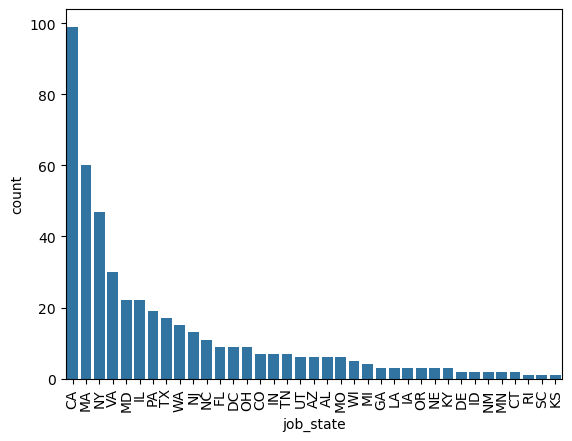

graph for same_state: total = 2


C:\Users\YUSUF MOShood\AppData\Local\Temp\ipykernel_1536\3301202459.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


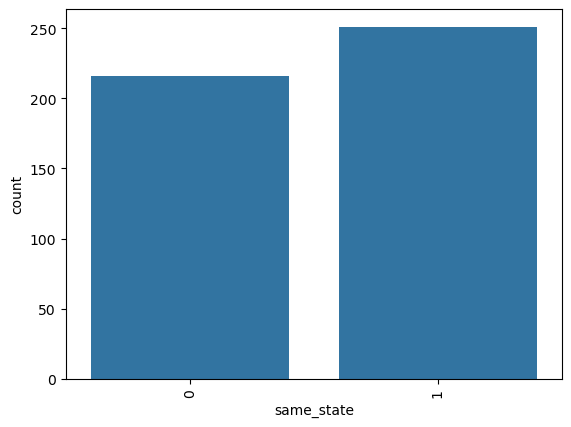

graph for spark: total = 2


C:\Users\YUSUF MOShood\AppData\Local\Temp\ipykernel_1536\3301202459.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


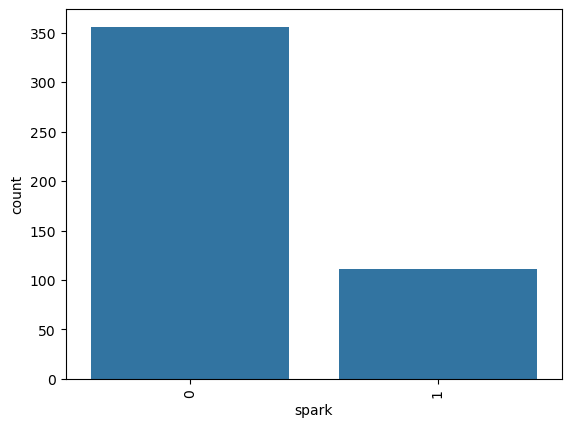

graph for aws: total = 2


C:\Users\YUSUF MOShood\AppData\Local\Temp\ipykernel_1536\3301202459.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


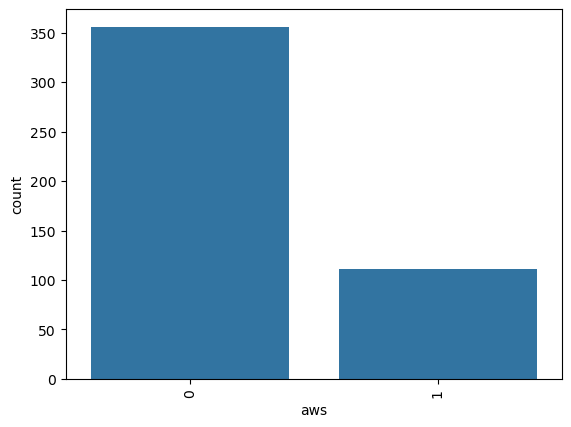

graph for excel: total = 2


C:\Users\YUSUF MOShood\AppData\Local\Temp\ipykernel_1536\3301202459.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


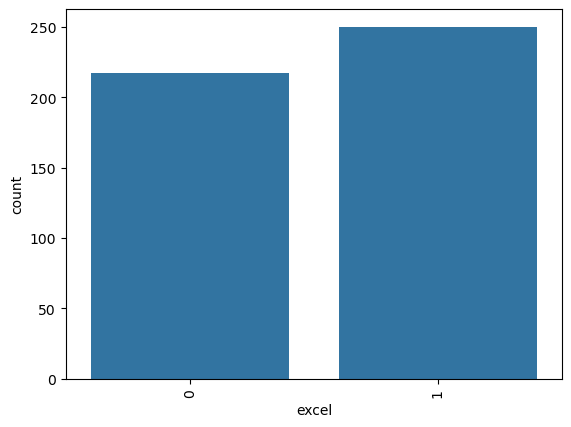

graph for job_simp: total = 7


C:\Users\YUSUF MOShood\AppData\Local\Temp\ipykernel_1536\3301202459.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


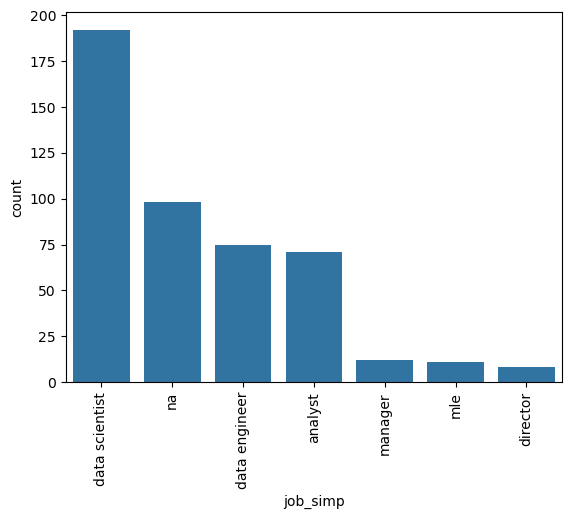

graph for seniority: total = 3


C:\Users\YUSUF MOShood\AppData\Local\Temp\ipykernel_1536\3301202459.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


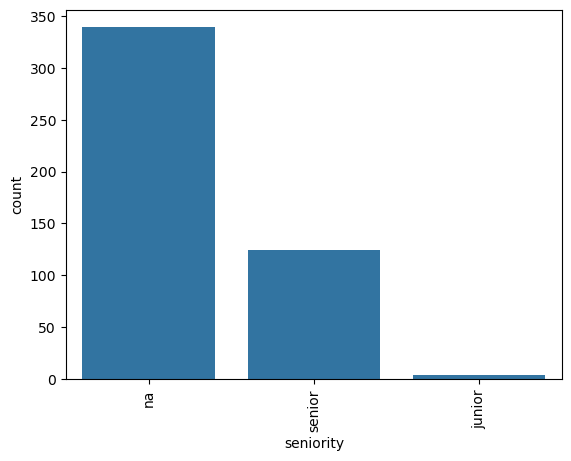

In [32]:
for i in df_cat.columns:
    cat_num = df_cat[i].value_counts()

    print("graph for %s: total = %d" % (i, len(cat_num)))
    chart= sns.barplot(x=cat_num.index,y=cat_num)
    chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
    plt.show()

graph for Location: total = 20


C:\Users\YUSUF MOShood\AppData\Local\Temp\ipykernel_1536\104147497.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


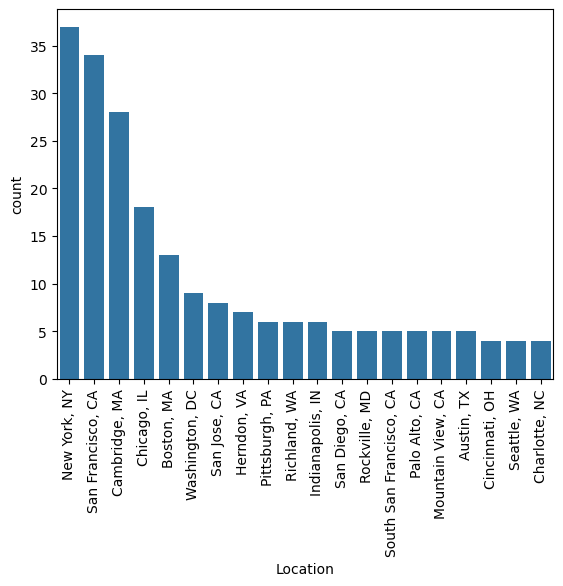

graph for Headquarters: total = 20


C:\Users\YUSUF MOShood\AppData\Local\Temp\ipykernel_1536\104147497.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


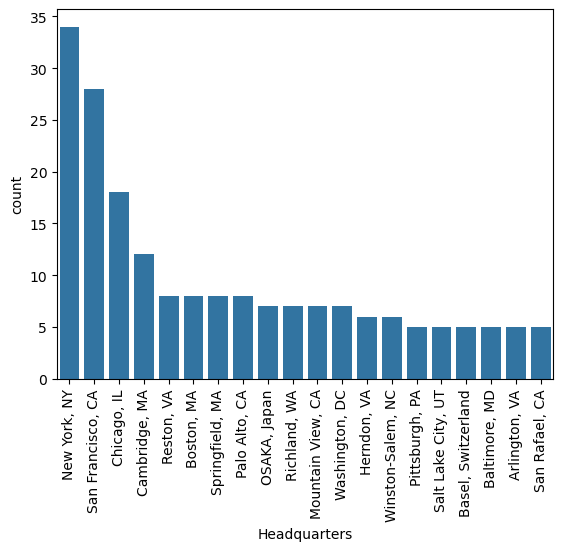

graph for company_txt: total = 20


C:\Users\YUSUF MOShood\AppData\Local\Temp\ipykernel_1536\104147497.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


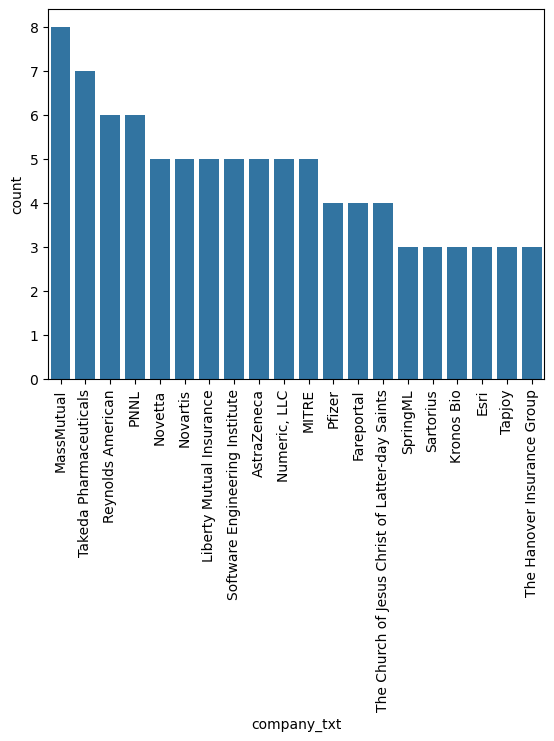

In [33]:
for i in df_cat[['Location','Headquarters','company_txt']].columns:
    cat_num = df_cat[i].value_counts()[:20]

    print("graph for %s: total = %d" % (i, len(cat_num)))
    chart= sns.barplot(x=cat_num.index,y=cat_num)
    chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
    plt.show()

In [34]:
pd.pivot_table(df, index='job_simp', values='avg_salary')

,avg_salary
job_simp,
analyst,68.225352
data engineer,102.866667
data scientist,115.906250
director,156.937500
manager,89.791667
mle,128.045455
na,87.780612


In [35]:
pd.pivot_table(df, index=['job_simp','seniority'], values='avg_salary')

avg_salary
job_simp       seniority            
analyst        junior      53.250000
               na          63.284314
               senior      83.888889
data engineer  na          96.061404
               senior     124.416667
data scientist junior     106.500000
               na         107.165441
               senior     137.690909
director       na         156.937500
manager        na          89.791667
mle            na         114.875000
               senior     163.166667
na             junior      62.500000
               na          77.559701
               senior     111.450000

In [36]:
pd.pivot_table(df, index=['job_state','job_simp'], values='avg_salary',aggfunc='count').sort_values('job_state', ascending=False)

avg_salary
job_state job_simp                  
WI        na                       1
          data scientist           2
          analyst                  2
WA        na                       1
          data scientist          11
...                              ...
AZ        analyst                  1
          na                       1
AL        na                       2
          data engineer            1
          analyst                  3

[114 rows x 1 columns]

In [37]:
pd.pivot_table(df[df.job_simp=='data scientist'], index=['job_state'], values='avg_salary').sort_values('avg_salary', ascending=False)

,avg_salary
job_state,
DC,147.500000
UT,140.500000
CA,139.062500
MO,119.750000
PA,116.625000
NY,114.446429
NC,113.250000
MD,112.444444
IL,112.250000


In [38]:
df.columns

Index(['Job Title', 'Salary Estimate', 'Job Description', 'Rating',
       'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'hourly', 'employer_provided', 'min_salary', 'max_salary', 'avg_salary',
       'company_txt', 'job_state', 'same_state', 'age', 'python_yn', 'r_yn',
       'spark', 'aws', 'excel', 'job_simp', 'seniority', 'desc_lenght',
       'no_Competitors'],
      dtype='object')

In [39]:
# rating,industry,sector,no_Competitors,hourly,employer_provided,r,spark,aws,excel,desc_lenght,type of ownership

In [40]:
df_pivots= df[['Rating', 'Industry', 'Sector','Revenue', 'no_Competitors', 'hourly', 'employer_provided','python_yn', 'r_yn',
           'spark', 'aws', 'excel','Type of ownership','avg_salary']]

In [41]:
df_pivots = df_pivots.dropna(subset=['avg_salary'])

for i in [c for c in df_pivots.columns if c not in ['avg_salary']]:
    print(f"\n--- {i} ---")
    print(pd.pivot_table(df_pivots, index=i, values='avg_salary', aggfunc='mean').sort_values('avg_salary', ascending=False))


--- Rating ---
        avg_salary
Rating            
-1.0    130.428571
 5.0    129.625000
 2.5    120.000000
 4.5    115.800000
 4.1    112.964286
 2.6    111.666667
 3.9    108.666667
 4.0    108.435484
 3.5    107.677419
 3.2    105.695652
 4.7    104.452381
 3.3    103.675000
 3.7    103.541667
 4.4    102.850000
 4.2    101.947368
 4.3     99.083333
 4.6     98.687500
 2.2     97.750000
 3.8     95.750000
 3.6     94.519231
 2.1     92.000000
 4.8     90.700000
 3.4     89.344828
 3.0     88.777778
 2.7     88.500000
 1.9     87.500000
 2.8     85.000000
 2.9     83.055556
 2.3     81.500000
 3.1     79.566667
 2.4     61.500000

--- Industry ---
                                          avg_salary
Industry                                            
Other Retail Stores                       163.500000
Motion Picture Production & Distribution  146.000000
Health, Beauty, & Fitness                 139.500000
Financial Analytics & Research            138.250000
Telecommunications Se

In [42]:
pd.pivot_table(df_pivots, index='Revenue',columns='python_yn',values='avg_salary',aggfunc='count')

python_yn,0,1
Revenue,,
$1 to $2 billion (USD),11.0,28.0
$1 to $5 million (USD),1.0,4.0
$10 to $25 million (USD),11.0,10.0
$10+ billion (USD),37.0,33.0
$100 to $500 million (USD),24.0,33.0
$2 to $5 billion (USD),11.0,15.0
$25 to $50 million (USD),14.0,8.0
$5 to $10 billion (USD),6.0,6.0
$5 to $10 million (USD),6.0,7.0


In [45]:
!pip install wordcloud

In [ ]:
import re
from wordcloud import WordCloud, STOPWORDS
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

In [ ]:
words = " ".join(df['Job Description'].fillna('').astype(str))


def punctuation_stop(text):
    stop_words = set(stopwords.words('english'))
    word_tokens = word_tokenize(text.lower())
    filtered = []
    for w in word_tokens:
        if w not in stop_words and w.isalpha():
            filtered.append(w)
    return " ".join(filtered)


words_filtered = punctuation_stop(words)
wc = WordCloud(
    background_color='white',
    random_state=1,
    stopwords=STOPWORDS,
    max_words=2000,
    width=800,
    height=1500
)
wc.generate(words_filtered)

plt.figure(figsize=(10, 10))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

LookupError: 
**********************************************************************
  Resource [93mstopwords[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('stopwords')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mcorpora/stopwords[0m

  Searched in:
    - 'C:\\Users\\YUSUF MOShood/nltk_data'
    - 'c:\\Users\\YUSUF MOShood\\anaconda3\\nltk_data'
    - 'c:\\Users\\YUSUF MOShood\\anaconda3\\share\\nltk_data'
    - 'c:\\Users\\YUSUF MOShood\\anaconda3\\lib\\nltk_data'
    - 'C:\\Users\\YUSUF MOShood\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
**********************************************************************
